## ECE 4510/5510: Machine Vision
## Homework #1
## Due date: October 6th, 2026

## Name: Reza, Jafarpourmarzouni
## Filename: Reza_Jafarpourmarzouni_hw1.ipynb

## Instructions
- Complete all problems in this Jupyter notebook. All code, figures, and results should appear directly in the notebook. 
- Write your solutions between the comments "BEGIN CODE HERE" and "END CODE HERE".
- Do not modify cells marked "DO NOT MODIFY THIS CELL". These are quick checks that should run without error if your code is correct.
- While not required, it is recommended to keep your code on github and frequently push changes to avoid losing your work.
- If generative AI is used, you must provide a brief description of how it was used in the comments.
- You are responsible for understanding all code that you submit.
- You may find the OpenCV documentation helpful: https://docs.opencv.org/5.0/

## Submission
- Submit the completed `.ipynb` file on Moodle using the filename `firstname_lastname_hw1.ipynb`, replacing `firstname_lastname` with your name.
- Before submitting, clear all outputs, restart the kernel, run all cells from beginning to end, and verify the notebook runs without errors.

In [3]:
#DO NOT MODIFY THIS CELL
#Import the libraries that will be used in this assignment
import cv2                          #For image processing functions
import numpy as np                  #For math functions
import matplotlib.pyplot as plt     #For plotting images and graphs
import os                           #For operating system dependent functions

#Print version of OpenCV
print('opencv version:', cv2.__version__)

opencv version: 4.11.0


# Problem 1 (20 points)

Download OpenCV's [`squirrel_cls.jpg`](https://raw.githubusercontent.com/opencv/opencv/5.x/samples/data/squirrel_cls.jpg) image and place it in the same directory as this notebook: https://raw.githubusercontent.com/opencv/opencv/5.x/samples/data/squirrel_cls.jpg

## Problem 1.1 (5/20 points)

Load the `squirrel_cls.jpg` image using `cv2.imread` and store the image in a variable named `image`.

Print the following:

- type of `image`
- image height
- image width
- number of channels in the image
- data type of pixels
- minimum intensity value
- maximum intensity value

**Tip:** `cv2.imread` returns the image as a NumPy `ndarray`. You may find the documentation for [`cv2.imread`](https://docs.opencv.org/5.0/main_modules/imgcodecs.html#imread), [`type()`](https://docs.python.org/3/library/functions.html#type), and [`ndarray`](https://numpy.org/doc/stable/reference/generated/numpy.ndarray.html) useful.


Image type: <class 'numpy.ndarray'>
image height: 426
image width: 535
image channels: 3
data type of the pixels: uint8
minimum intensity value of the pixels: 0
maximum intensity value of the pixels: 255


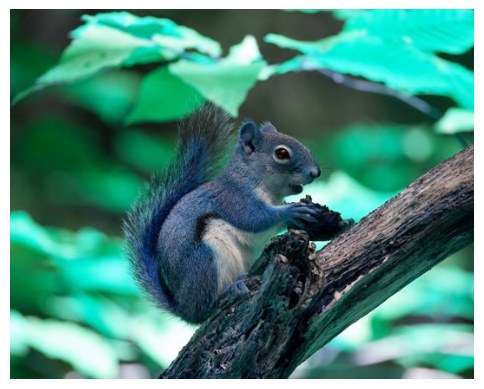

In [9]:
# BEGIN CODE HERE

image = cv2.imread('squirrel_cls.jpg') #Read the image
print(f"Image type: {type(image)}") #Print the type of the image
print(f"image height: {image.shape[0]}") #Print the height of the image
print(f"image width: {image.shape[1]}") #Print the width of the image
print(f"image channels: {image.shape[2]}") #Print the number of channels of the image
print(f"data type of the pixels: {image.dtype}") #Print the data type of the pixels
print(f"minimum intensity value of the pixels: {image.min()}") #Print the minimum intensity value of the pixels
print(f"maximum intensity value of the pixels: {image.max()}") #Print the maximum intensity value of the pixels
plt.axis('off') #Turn off axis
plt.imshow(image) #Display the image

# END CODE HERE

## Problem 1.2 (5/20 points)

OpenCV loads color images in BGR order.

Convert `image` from BGR to RGB using `cv2.cvtColor` and store the result in `image_rgb`.

Display `image_rgb` using `matplotlib` with the axes off.

**Tip:** You may find the documentation for [`cv2.cvtColor`](https://docs.opencv.org/doc/doxygen/html/d8/d01/group__imgproc__color__conversions.html#gaf86c09fe702ed037c03c2bc603ceab14), [`plt.imshow`](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.imshow.html), and [`plt.axis`](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.axis.html) useful.

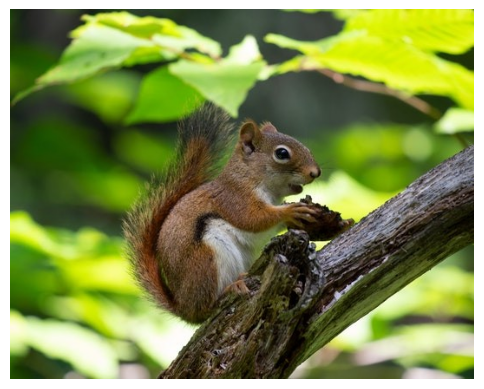

In [12]:
# BEGIN CODE HERE

image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB) #Convert the image to RGB
plt.axis('off') #Turn off axis
plt.imshow(image_rgb) #Display the RGB image

# END CODE HERE

## Problem 1.3 (5/20 points)

Extract rows 125–225 and columns 250–360 from `image_rgb` and store the result in `crop`.

Create a copy of `image_rgb` and mark the selected region with a rectangle in the copied image.

Display the following images side by side:

1. the copied image with the selected region marked by a rectangle
2. the cropped region by itself

**Tip:** You may find the documentation for [NumPy indexing](https://numpy.org/doc/stable/user/basics.indexing.html), [`ndarray.copy`](https://numpy.org/doc/stable/reference/generated/numpy.ndarray.copy.html), [`cv2.rectangle`](https://docs.opencv.org/5.0/main_modules/imgproc_draw.html#rectangle), [`plt.subplot`](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.subplot.html), and [`plt.title`](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.title.html) useful.

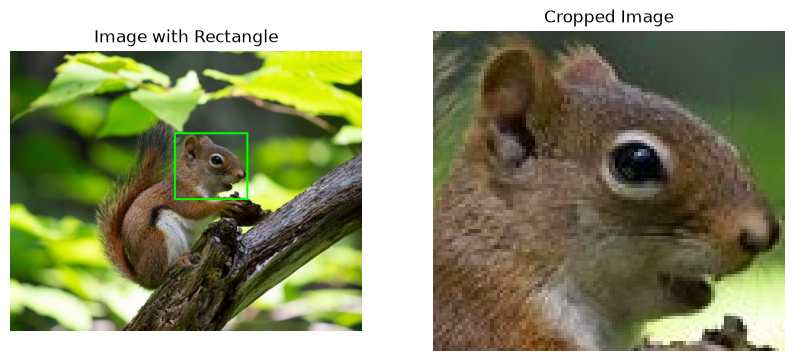

In [95]:
# BEGIN CODE HERE

crop = image_rgb[125:225, 250:360] #Crop the image
image_rgb_copy = image_rgb.copy() #Make a copy of the RGB image
image_with_rectangle = cv2.rectangle(image_rgb_copy, (250, 125), (360, 225), (0, 255, 0), 2) #Draw a green rectangle around the cropped region

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1) #Create a subplot with 1 row and 2 columns, and select the first subplot
plt.axis('off') #Turn off axis
plt.title("Image with Rectangle")
plt.imshow(image_with_rectangle) #Display the image with the rectangle

plt.subplot(1, 2, 2) #Create a subplot with 1 row and 2 columns, and select the second subplot
plt.axis('off') #Turn off axis
plt.title("Cropped Image")
plt.imshow(crop) #Display the cropped image

# END CODE HERE

## Problem 1.4 (5/20 points)

Save the cropped region as `crop.jpg` in the same directory as this notebook using `cv2.imwrite`.

Remember that `crop` is currently stored in RGB order, but `cv2.imwrite` expects a color image in BGR order.

**Tip:** You may find the documentation for [`cv2.imwrite`](https://docs.opencv.org/5.0/main_modules/imgcodecs.html#imwrite) useful.


In [28]:
# BEGIN CODE HERE

cv2.imwrite('crop.jpg', cv2.cvtColor(crop, cv2.COLOR_RGB2BGR)) #Save the cropped image as a new file

# END CODE HERE

True

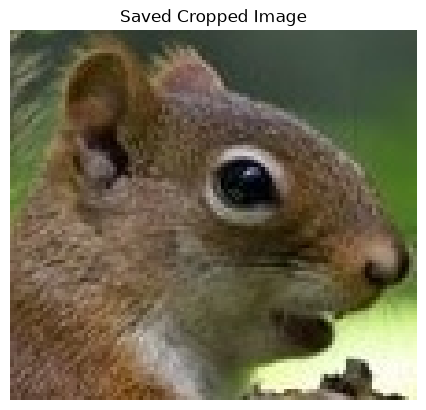

In [94]:
# DO NOT MODIFY THIS CELL
assert os.path.exists("crop.jpg")

saved_crop = cv2.imread("crop.jpg")
saved_crop_rgb = cv2.cvtColor(saved_crop, cv2.COLOR_BGR2RGB)

plt.imshow(saved_crop_rgb)
plt.axis("off")
plt.title("Saved Cropped Image")
plt.show()


# Problem 2 (20 points)

Download OpenCV's [`smarties.png`](https://raw.githubusercontent.com/opencv/opencv/5.x/samples/data/smarties.png) and place it in the same directory as this notebook.


## Problem 2.1 (5/20 points)

Load `smarties.png` and convert it from BGR to RGB. Store the RGB image in `smarties_rgb`.

Extract the red, green, and blue channels into separate arrays with names:

- `r`
- `g`
- `b`

Display the color image and the three individual channels side by side. Display each individual channel as a grayscale image.

**Tip:** You may find the documentation for `matplotlib` [colormaps](https://matplotlib.org/stable/users/explain/colors/colormaps.html) useful. In particular, you should look at the `cmap` argument for `plt.imshow`. When displaying a single channel, `matplotlib` will apply its default colormap if one is not specified.

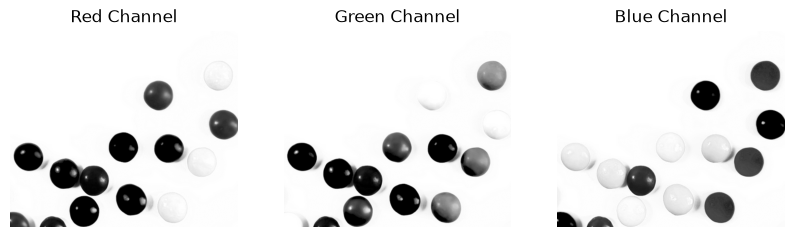

In [93]:
# BEGIN CODE HERE

smarties_rgb = cv2.imread("smarties.png", cv2.COLOR_BGR2RGB) #Read the smarties image and convert it to RGB
r = smarties_rgb[:, :, 0] #Extract the red channel
g = smarties_rgb[:, :, 1] #Extract the green channel
b = smarties_rgb[:, :, 2] #Extract the blue channel

plt.figure(figsize=(10, 5))

plt.subplot(1, 3, 1) #Create a subplot with 1 row and 3 columns, and select the first subplot
plt.axis('off') #Turn off axis
plt.title('Red Channel')
plt.imshow(r, cmap='gray') #Display the red channel in grayscale

plt.subplot(1, 3, 2) #Create a subplot with 1 row and 3 columns, and select the second subplot
plt.axis('off') #Turn off axis
plt.title('Green Channel')
plt.imshow(g, cmap='gray') #Display the green channel in grayscale

plt.subplot(1, 3, 3) #Create a subplot with 1 row and 3 columns, and select the third subplot
plt.axis('off') #Turn off axis
plt.title('Blue Channel')
plt.imshow(b, cmap='gray') #Display the blue channel in grayscale

# END CODE HERE

## Problem 2.2 (5/20 points)

Convert the RGB image to grayscale using

$$
I_{\text{average}}
=
\frac{r+g+b}{3}.
$$

You will need to convert the data type to floating point to avoid overflow.

Convert the resulting grayscale image back to `uint8`, store it in `gray_average`, and display it.

**Tip:** You may find the documentation for [`ndarray.astype`](https://numpy.org/doc/stable/reference/generated/numpy.ndarray.astype.html) useful for converting between data types.

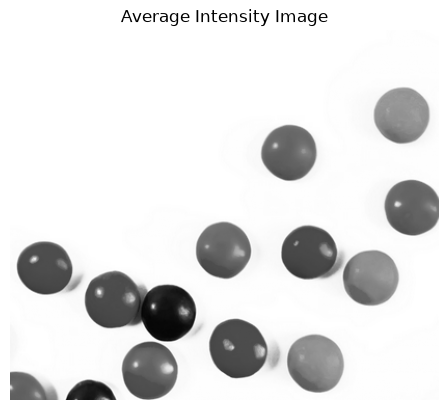

In [92]:
# BEGIN CODE HERE

I_average = (r.astype(np.float32) + g.astype(np.float32) + b.astype(np.float32)) / 3 #Compute the average intensity image
grey_average = I_average.astype(np.uint8) #Convert the average intensity image to uint8
plt.axis('off') #Turn off axis
plt.title('Average Intensity Image')
plt.imshow(grey_average, cmap='gray') #Display the average intensity image

# END CODE HERE

## Problem 2.3 (5/20 points)

Create a second grayscale image using

$$
I_{\text{weighted}}
=
0.299r + 0.587g + 0.114b.
$$

Convert the result to `uint8`, store it in `gray_weighted`, and display it.

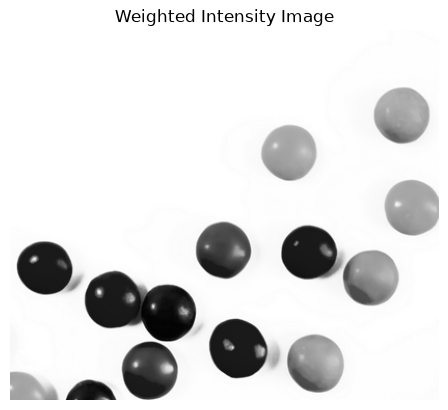

In [91]:
# BEGIN CODE HERE

I_weighted = 0.299 * r.astype(np.float32) + 0.587 * g.astype(np.float32) + 0.114 * b.astype(np.float32) #Compute the weighted intensity image
grey_weighted = I_weighted.astype(np.uint8) #Convert the weighted intensity image to uint8
plt.axis('off') #Turn off axis
plt.title('Weighted Intensity Image') 
plt.imshow(grey_weighted, cmap='gray') #Display the weighted intensity image

# END CODE HERE

## Problem 2.4 (5/20 points)

Concatenate `gray_average` and `gray_weighted` horizontally using `np.concatenate`.

Store the result in `gray_compare` and display the resulting image.

**Tip:** You may find the documentation for [`np.concatenate`](https://numpy.org/doc/stable/reference/generated/numpy.concatenate.html) useful. In particular, you should pay attention to the `axis` argument.

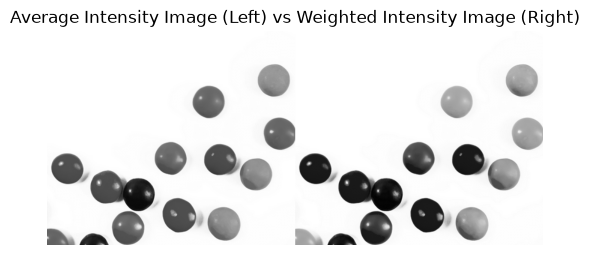

In [90]:
# BEGIN CODE HERE

gray_compare = np.concatenate((grey_average, grey_weighted), axis=1) #Concatenate the average and weighted intensity images horizontally
plt.axis('off') #Turn off axis
plt.title('Average Intensity Image (Left) vs Weighted Intensity Image (Right)')
plt.imshow(gray_compare, cmap='gray') #Display the concatenated image

# END CODE HERE

In [42]:
# DO NOT MODIFY THIS CELL
assert gray_compare.shape[0] == smarties_rgb.shape[0]
assert gray_compare.shape[1] == 2 * smarties_rgb.shape[1]


# Problem 3 (15 points)

Download OpenCV's [`building.jpg`](https://raw.githubusercontent.com/opencv/opencv/5.x/samples/data/building.jpg) and place it in the same directory as this notebook.


## Problem 3.1 (5/15 points)

Load `building.jpg`, convert it from BGR to RGB, store it in `building_rgb`, and display it.

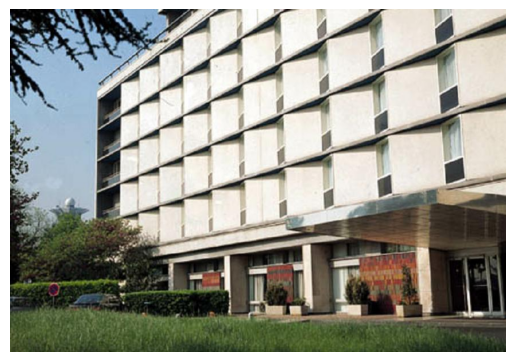

In [62]:
# BEGIN CODE HERE
building_rgb = cv2.cvtColor(cv2.imread("building.jpg"), cv2.COLOR_BGR2RGB) #Convert the image to RGB
plt.axis('off') #Turn off axis
plt.imshow(building_rgb) #Display the building image

# END CODE HERE

## Problem 3.2 (5/15 points)

Write a function `adjust_brightness(image, scale)`

The function will change the brightness of an image by multiplying each pixel value by `scale`.

Your function should:

1. Create an output image with the same dimensions and data type as the input image using `np.zeros_like`.
2. Use two nested `for` loops to visit every pixel in the image.
3. Multiply the RGB values of each pixel by `scale`.
4. Clip the resulting values to the valid range $[0,255]$ using `np.clip`.
5. Store the resulting pixel in the output image.
6. Return the output image.

Do not perform the operation on the entire image at the same time. The purpose of this problem is to practice accessing and modifying individual pixels.

**Tip:** You may find the documentation for [`np.zeros_like`](https://numpy.org/doc/stable/reference/generated/numpy.zeros_like.html) and [`np.clip`](https://numpy.org/doc/stable/reference/generated/numpy.clip.html) useful.

In [47]:
def adjust_brightness(image, scale):
    """
    Inputs:
        image: RGB image stored as a NumPy array with shape (height, width, 3).
        scale: Scalar brightness factor.

    Output:
        output: RGB image with the same shape and data type as the input image.
    
    AI was used to create this docstring.
    """
    # BEGIN CODE HERE
    adjusted_image = np.zeros_like(image) #Create an empty image with the same shape and data type as the input image
    for row in range(image.shape[0]):
        for col in range(image.shape[1]):
            adjusted_image[row, col] = image[row, col] * scale #Adjust the brightness of each pixel
            adjusted_image[row, col] = np.clip(adjusted_image[row, col], 0, 255) #Clip the pixel values to be in the range [0, 255]
    adjusted_image = adjusted_image.astype(np.uint8) #Convert the adjusted image to uint8
    return adjusted_image
            

    # END CODE HERE


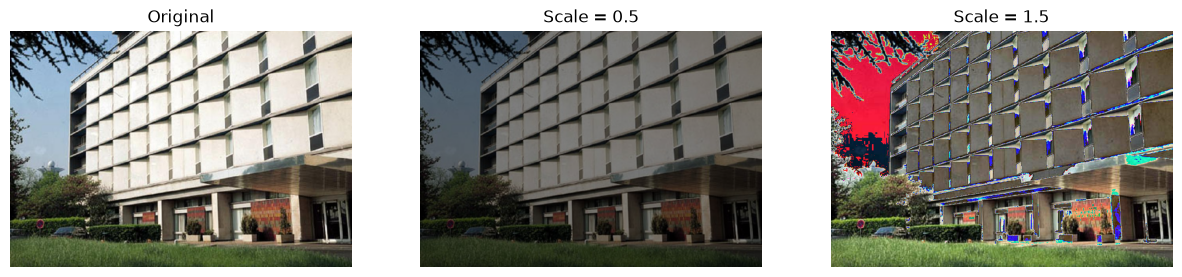

In [63]:
# DO NOT MODIFY THIS CELL
building_dark = adjust_brightness(building_rgb, 0.5)
building_bright = adjust_brightness(building_rgb, 1.5)

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(building_rgb)
plt.title("Original")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(building_dark)
plt.title("Scale = 0.5")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(building_bright)
plt.title("Scale = 1.5")
plt.axis("off")

plt.show()

assert building_dark.shape == building_rgb.shape
assert building_bright.shape == building_rgb.shape
assert building_dark.dtype == building_rgb.dtype
assert building_bright.dtype == building_rgb.dtype


## Problem 3.3 (5/15 points)

Write a function `resize_image(image, new_width, new_height)` that resizes an image using nearest-neighbor interpolation.

The function should:

1. Determine the height and width of the input image.
2. Create an output image with dimensions `new_height` × `new_width` using `np.zeros`.
3. Use two nested `for` loops to visit every pixel in the output image.
4. Determine which pixel in the input image corresponds to each output pixel.
5. Copy the nearest input pixel to the output image.
6. Return the resized image.

For an output pixel $(u',v')$, you can compute the corresponding location in the input image as

$$
u = u'\frac{W}{W'},
\qquad
v = v'\frac{H}{H'},
$$

where $W$ and $H$ are the width and height of the input image, and $W'$ and $H'$ are the width and height of the output image.

Do not use `cv2.resize` or another function that performs the resizing for you.

**Tip:** You may find the documentation for [`np.zeros`](https://numpy.org/doc/stable/reference/generated/numpy.zeros.html) and [`int()`](https://docs.python.org/3/library/functions.html#int) useful.


In [49]:
def resize_image(image, new_width, new_height):
    """
    Inputs:
        image: RGB image stored as a NumPy array with shape (height, width, 3).
        new_width: Desired width of the resized image in pixels.
        new_height: Desired height of the resized image in pixels.

    Output:
        output: Resized RGB image with shape (new_height, new_width, 3).

    AI was used to create this docstring.
    """

    # BEGIN CODE HERE
    resized_image = np.zeros((new_height, new_width, 3), dtype=image.dtype) #Create an empty image with the desired shape and the same data type as the input image
    for row in range(new_height):
        for col in range(new_width):
            orig_row = int(row * image.shape[0] / new_height) #Compute the corresponding row in the original image
            orig_col = int(col * image.shape[1] / new_width) #Compute the corresponding column in the original image
            resized_image[row, col] = image[orig_row, orig_col] #Assign the pixel value from the original image to the resized image
    return resized_image

    # END CODE HERE

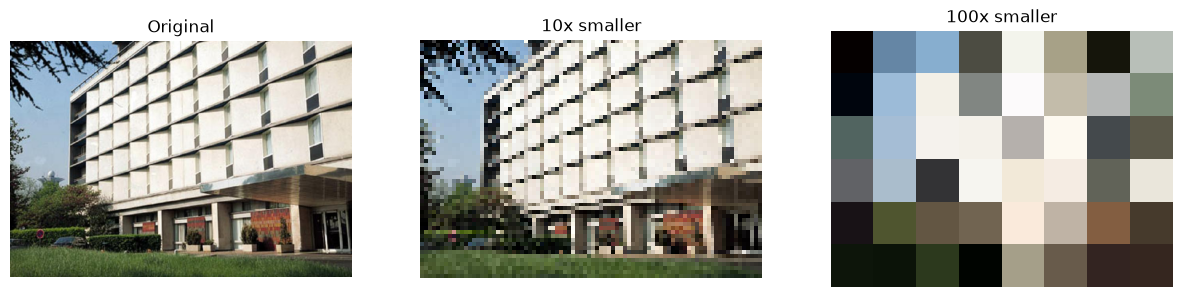

In [64]:
# DO NOT MODIFY THIS CELL
building_small = resize_image(building_rgb, int(building_rgb.shape[1]/10), int(building_rgb.shape[0]/10))
building_tiny = resize_image(building_rgb, int(building_rgb.shape[1]/100), int(building_rgb.shape[0]/100))

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(building_rgb)
plt.title("Original")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(building_small)
plt.title("10x smaller")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(building_tiny)
plt.title("100x smaller")
plt.axis("off")

plt.show()

assert building_small.shape[:2] == (
    int(building_rgb.shape[0] / 10),
    int(building_rgb.shape[1] / 10)
)
assert building_tiny.shape[:2] == (
    int(building_rgb.shape[0] / 100),
    int(building_rgb.shape[1] / 100)
)


# Problem 4 (15 points)

Download OpenCV's [`baboon.jpg`](https://raw.githubusercontent.com/opencv/opencv/5.x/samples/data/baboon.jpg) and place it in the same directory as this notebook.

## Problem 4.1 (5/15 points)
Load `baboon.jpg`, convert it from BGR to RGB, store it in `baboon_rgb`, and display it.

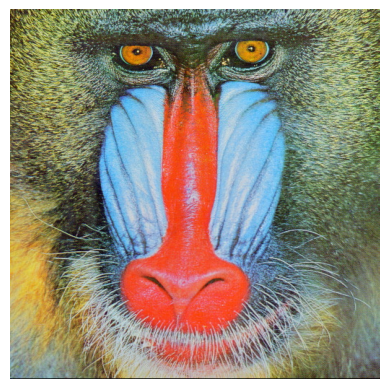

In [ ]:
# BEGIN CODE HERE

baboon_rgb = cv2.cvtColor(cv2.imread("baboon.jpg"), cv2.COLOR_BGR2RGB) #Convert the image to RGB
plt.axis('off') #Turn off axis
plt.imshow(baboon_rgb) #Display the baboon image

# END CODE HERE

## Problem 4.2 (5/15 points)

Write a function `translate_image(image, t_u, t_v)`.

* The function will translate an image by $t_u$ pixels horizontally and $t_v$ pixels vertically.
* Positive $t_u$ should move the image to the right.
* Positive $t_v$ should move the image down.

Create an output image with the same size as the input image using `np.zeros_like`.

For each input pixel $(u,v)$:

1. Compute its location in the output image:

$$
u' = u + t_u
$$

$$
v' = v + t_v
$$

2. If $(u',v')$ lies inside the output image, copy the RGB value from the input pixel to the output pixel.

Recall, the indices for NumPy images are `image[v, u]`.

Do not use any existing function that will translate the image for you.

Test your function by translating the image:

* 100 pixels to the right and 50 pixels down.
* 100 pixels to the left and 50 pixels up.


In [69]:
def translate_image(image, t_u, t_v):
    """
    Inputs:
        image: RGB image stored as a NumPy array with shape (height, width, 3).
        t_u: Horizontal translation in pixels. Positive values shift the image to the right.
        t_v: Vertical translation in pixels. Positive values shift the image downward.

    Output:
        output: Translated RGB image with the same shape and data type as the input image.

    AI was used to create this docstring.
    """
    # BEGIN CODE HERE

    translated_image = np.zeros_like(image) #Create an empty image with the same shape and data type as the input image
    for row in range(image.shape[0]):
        for col in range(image.shape[1]):
            new_row = row + t_v #Compute the new row index after translation
            new_col = col + t_u #Compute the new column index after translation
            if 0 <= new_row < image.shape[0] and 0 <= new_col < image.shape[1]: #Check if the new indices are within bounds
                translated_image[new_row, new_col] = image[row, col] #Assign the pixel value to the new location
    return translated_image
    # END CODE HERE

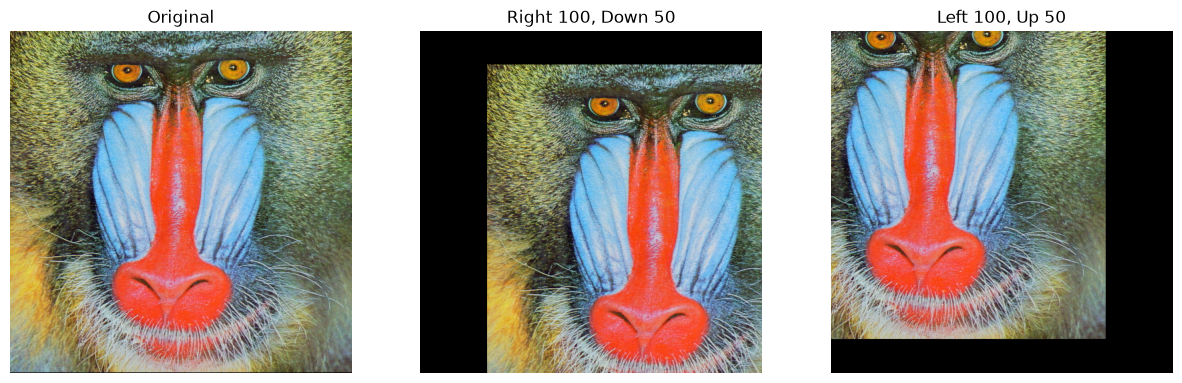

In [70]:
# DO NOT MODIFY THIS CELL
translated_1 = translate_image(baboon_rgb, 100, 50)
translated_2 = translate_image(baboon_rgb, -100, -50)

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(baboon_rgb)
plt.title("Original")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(translated_1)
plt.title("Right 100, Down 50")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(translated_2)
plt.title("Left 100, Up 50")
plt.axis("off")

plt.show()

assert translated_1.shape == baboon_rgb.shape
assert translated_2.shape == baboon_rgb.shape

## Problem 4.3 (5/15 points)

Write a function `rotate_image(image, theta)`
- The function will rotate an image by an angle $\theta$ about the center of the image.
- The positive angles should rotate the image counterclockwise.

Create an output image with the same size as the input image using `np.zeros_like`.

For each output pixel $(u',v')$:
1. Subtract the image center $(c_u,c_v)$.
2. Map the output pixel back to the input image using the following:
$$x = \cos(\theta)x' - \sin(\theta)y'$$
$$y = \sin(\theta)x' + \cos(\theta)y'$$
3. Add the image center back and round to the nearest pixel.
4. If the resulting pixel lies inside the input image, copy its RGB value to the output image.

Recall, the indices for NumPy images are `image[v, u]`.

Do not use any existing function that will rotate the image for you.

**Tip:** NumPy's trigonometric functions expect angles in radians. You may find the documentation for [`np.deg2rad`](https://numpy.org/doc/stable/reference/generated/numpy.deg2rad.html), [`np.cos`](https://numpy.org/doc/stable/reference/generated/numpy.cos.html), [`np.sin`](https://numpy.org/doc/stable/reference/generated/numpy.sin.html), and [`round()`](https://docs.python.org/3/library/functions.html#round) useful.


In [73]:
def rotate_image(image, theta):
    """
    Inputs:
        image: RGB image stored as a NumPy array with shape (height, width, 3).
        theta: Rotation angle in degrees. Positive values rotate the image counterclockwise.

    Output:
        output: Rotated RGB image with the same shape and data type as the input image.

    AI was used to create this docstring.
    """
    # BEGIN CODE HERE

    rotated_image = np.zeros_like(image) #Create an empty image with the same shape and data type as the input image
    center_row = image.shape[0] / 2 #Compute the center row of the image
    center_col = image.shape[1] / 2 #Compute the center column of the image
    theta_rad = np.deg2rad(theta) #Convert the rotation angle from degrees to radians
    cos_theta = np.cos(theta_rad) #Compute the cosine of the rotation angle
    sin_theta = np.sin(theta_rad) #Compute the sine of the rotation angle

    for row in range(image.shape[0]):
        for col in range(image.shape[1]):
            # Translate pixel to origin
            translated_row = row - center_row
            translated_col = col - center_col
            
            # Rotate pixel
            rotated_row = int(translated_row * cos_theta - translated_col * sin_theta)
            rotated_col = int(translated_row * sin_theta + translated_col * cos_theta)
            
            # Translate pixel back
            new_row = round(rotated_row + center_row)
            new_col = round(rotated_col + center_col)
            
            if 0 <= new_row < image.shape[0] and 0 <= new_col < image.shape[1]: #Check if the new indices are within bounds
                rotated_image[new_row, new_col] = image[row, col] #Assign the pixel value to the new location
    return rotated_image
    # END CODE HERE

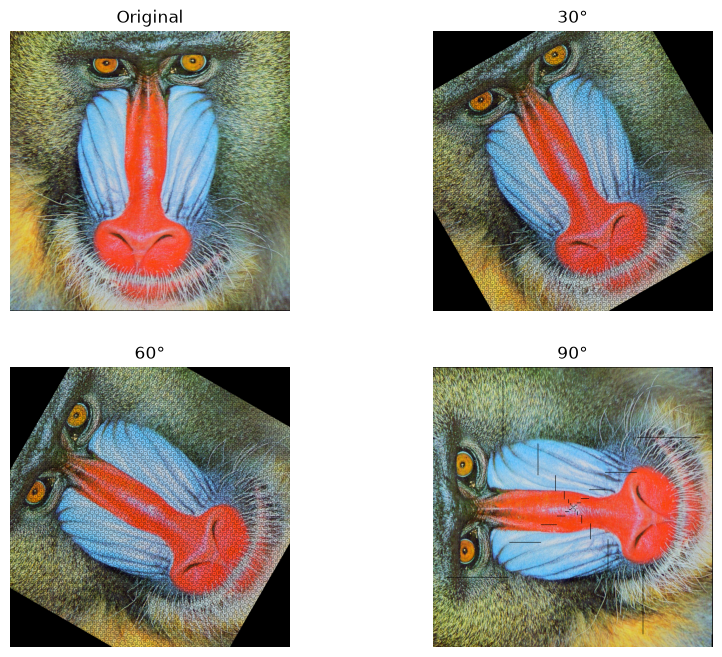

In [74]:
# DO NOT MODIFY THIS CELL
baboon_30 = rotate_image(baboon_rgb, 30)
baboon_60 = rotate_image(baboon_rgb, 60)
baboon_90 = rotate_image(baboon_rgb, 90)

plt.figure(figsize=(10, 8))

plt.subplot(2, 2, 1)
plt.imshow(baboon_rgb)
plt.title("Original")
plt.axis("off")

plt.subplot(2, 2, 2)
plt.imshow(baboon_30)
plt.title("30°")
plt.axis("off")

plt.subplot(2, 2, 3)
plt.imshow(baboon_60)
plt.title("60°")
plt.axis("off")

plt.subplot(2, 2, 4)
plt.imshow(baboon_90)
plt.title("90°")
plt.axis("off")

plt.show()

assert baboon_30.shape == baboon_rgb.shape
assert baboon_60.shape == baboon_rgb.shape
assert baboon_90.shape == baboon_rgb.shape
assert np.array_equal(rotate_image(baboon_rgb, 0), baboon_rgb)

# Problem 5 (20 points)

Consider a camera with image width $W=640$ pixels and height $H=480$ pixels.

The eight points below define the corners of a cube expressed in the **camera coordinate frame**.

Assume the camera coordinate frame has:

- $X$ pointing right
- $Y$ pointing down
- $Z$ pointing forward

Write a function `project_points(K, points)`

The function will take an $N\times3$ array of 3D points in the camera coordinate frame and return the corresponding $N\times2$ pixel coordinates.

For each point, compute

$$
\begin{bmatrix}
\tilde{u}\\
\tilde{v}\\
\tilde{w}
\end{bmatrix}
=
K
\begin{bmatrix}
X\\
Y\\
Z
\end{bmatrix},
$$

followed by

$$
u = \frac{\tilde{u}}{\tilde{w}},
\qquad
v = \frac{\tilde{v}}{\tilde{w}}.
$$

Do not use `cv2.projectPoints`.


In [75]:
# DO NOT MODIFY THIS CELL
image_width = 640
image_height = 480

K = np.array([
    [500,   0, 320],
    [  0, 500, 240],
    [  0,   0,   1]
], dtype=float)

# The points on the cube expressed in the camera coordinate frame.
vertices = np.array([
    [-1.366, -1.061, 5.905],
    [ 0.366, -1.319, 4.939],
    [ 0.366,  0.612, 4.422],
    [-1.366,  0.871, 5.388],
    [-0.366, -0.612, 7.578],
    [ 1.366, -0.871, 6.612],
    [ 1.366,  1.061, 6.095],
    [-0.366,  1.319, 7.061]
], dtype=float)

# The pairs of points defining the edges of the cube.
edges = [
    (0, 1), (1, 2), (2, 3), (3, 0),
    (4, 5), (5, 6), (6, 7), (7, 4),
    (0, 4), (1, 5), (2, 6), (3, 7)
]

# Sample points along each edge of the cube to make dense point cloud.
cube_points = []

for i, j in edges:
    edge_points = np.linspace(vertices[i], vertices[j], 500)
    cube_points.append(edge_points)

cube_points = np.vstack(cube_points)

## Problem 5.1 (10/20 points)

Write a function `project_points(K, points)` that projects a set of 3D points from the camera coordinate frame into the image.

The input `points` is an $N\times3$ NumPy array. Each row contains a point

$$
\begin{bmatrix}
X & Y & Z
\end{bmatrix}.
$$

For each point, compute

$$
\begin{bmatrix}
\tilde{u}\\
\tilde{v}\\
\tilde{w}
\end{bmatrix}
=
K
\begin{bmatrix}
X\\
Y\\
Z
\end{bmatrix},
$$

and then compute the pixel coordinates

$$
u = \frac{\tilde{u}}{\tilde{w}},
\qquad
v = \frac{\tilde{v}}{\tilde{w}}.
$$

Return the projected points as an $N\times2$ NumPy array, where each row contains

$$
\begin{bmatrix}
u & v
\end{bmatrix}.
$$

Do not use `cv2.projectPoints`.

**Tip:** You may find the documentation for [`np.matmul`](https://numpy.org/doc/stable/reference/generated/numpy.matmul.html) and [`ndarray.T`](https://numpy.org/doc/stable/reference/generated/numpy.ndarray.T.html) useful. The `@` operator can be used for matrix multiplication.

In [76]:
def project_points(K, points):
    """
    Inputs:
        K: Camera intrinsic matrix stored as a NumPy array with shape (3, 3).
        points: 3D points in the camera coordinate frame stored as a NumPy array with shape (N, 3).

    Output:
        pixels: Projected pixel coordinates stored as a NumPy array with shape (N, 2).

    AI was used to create this docstring.
    """
    # BEGIN CODE HERE

    projected_points = np.zeros((points.shape[0], 2)) #Create an empty array to store the projected pixel coordinates
    for row in range(points.shape[0]):
        point_3d = points[row] #Get the 3D point
        point_2d_homogeneous = np.matmul(K, point_3d) #Project the 3D point to 2D homogeneous coordinates using the camera intrinsic matrix
        projected_points[row] = point_2d_homogeneous[:2] / point_2d_homogeneous[2] #Convert from homogeneous to Cartesian coordinates
    return projected_points
    # END CODE HERE


In [77]:
# DO NOT MODIFY THIS CELL
cube_pixels = project_points(K, cube_points)

assert isinstance(cube_pixels, np.ndarray)
assert cube_pixels.shape == (cube_points.shape[0], 2)
assert np.all(np.isfinite(cube_pixels))

## Problem 5.2 (10/20 points)

Write a function

`points_to_image(points, image_width, image_height)`

that creates an image containing the projected points.

The input `points` is an $N\times2$ array containing pixel coordinates $(u,v)$.

Your function should:

1. Create a black RGB image with the specified width and height.
2. Loop through each projected point.
3. Round $u$ and $v$ to the nearest integer pixel.
4. Check that the pixel lies inside the image.
5. Set the corresponding pixel to white.
6. Return the resulting image.

Recall that NumPy images are indexed as `image[v, u]`.

**Tip:** You may find the documentation for [`np.round`](https://numpy.org/doc/stable/reference/generated/numpy.round.html) useful.

In [78]:
def points_to_image(points, image_width, image_height):
    """
    Inputs:
        points: Pixel coordinates stored as a NumPy array with shape (N, 2).
        image_width: Width of the output image in pixels.
        image_height: Height of the output image in pixels.

    Output:
        image: RGB image containing the projected points with shape (image_height, image_width, 3).

    AI was used to create this docstring.
    """
    # BEGIN CODE HERE

    image = np.zeros((image_height, image_width, 3), dtype=np.uint8) #Create an empty RGB image with the specified width and height
    for point in points:
        x, y = int(point[0]), int(point[1]) #Get the pixel coordinates
        if 0 <= x < image_width and 0 <= y < image_height: #Check if the pixel coordinates are within bounds
            image[y, x] = [255, 255, 255] #Set the pixel value to white
    return image

    # END CODE HERE


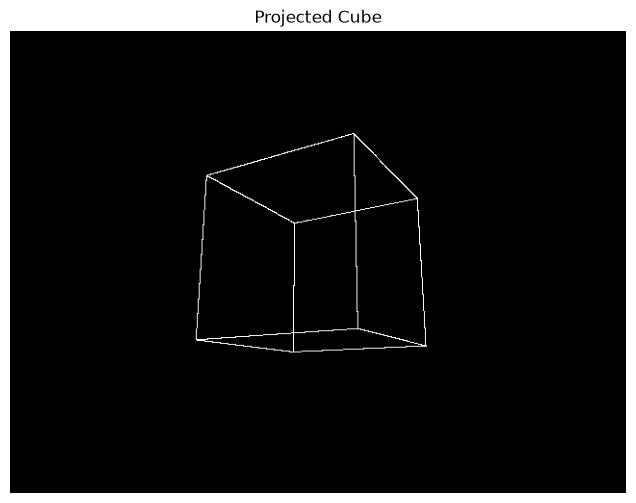

In [79]:
# DO NOT MODIFY THIS CELL
cube_pixels = project_points(K, cube_points)

cube_image = points_to_image(
    cube_pixels,
    image_width,
    image_height
)

plt.figure(figsize=(8, 6))
plt.imshow(cube_image)
plt.title("Projected Cube")
plt.axis("off")
plt.show()

assert isinstance(cube_image, np.ndarray)
assert cube_image.shape == (image_height, image_width, 3)
assert cube_image.dtype == np.uint8
assert np.any(cube_image != 0)

## Problem 6 (10 points)

Do something with an image that we have not already done in this assignment.

Your solution should:

* perform at least one image processing or manipulation operation not already done in this assignment
* display the original image and your resulting image (or images)
* include a short comment describing your goal
* include a short comment describing any new functions or methods you used

You may use any image from this assignment or another image of your choice.


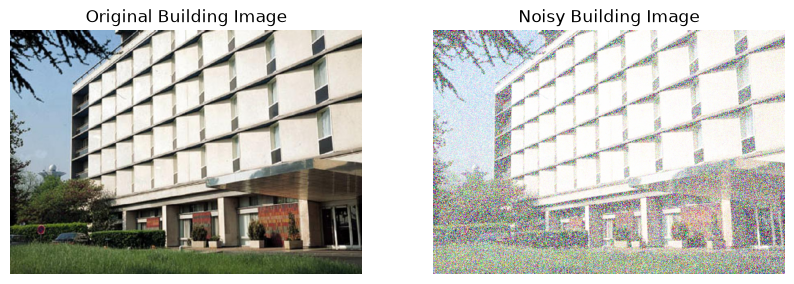

In [89]:
# BEGIN CODE HERE

"I want to add gaussian noise to the building image and see how it changes the image."

building_noisy = building_rgb.copy() #Make a copy of the building image
mean = 0 #Mean of the Gaussian noise
std_dev = 25 #Standard deviation of the Gaussian noise
gaussian_noise = np.random.normal(mean, std_dev, building_noisy.shape).astype(np.uint8) #Generate Gaussian noise with the same shape as the building image
building_noisy = cv2.add(building_noisy, gaussian_noise) #Add the Gaussian noise to the building image

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1) #Create a subplot with 1 row and 2 columns, and select the first subplot
plt.axis('off') #Turn off axis
plt.title('Original Building Image')
plt.imshow(building_rgb) #Display the original building image

plt.subplot(1, 2, 2) #Create a subplot with 1 row and 2 columns, and select the second subplot
plt.axis('off') #Turn off axis
plt.title('Noisy Building Image') 
plt.imshow(building_noisy) #Display the noisy building image

# END CODE HERE